# ch301 — What is Deep Learning?

## 1. The core claim

Deep learning is the practice of approximating functions by composing many simple, parameterised
operations and adjusting parameters via gradient-guided optimisation.

That sentence is precise. Every word matters:

- **Approximating functions**: we do not derive the mapping analytically; we search for it.
- **Composing**: the power comes from depth — chaining simple transformations.
- **Parameterised**: every operation has tunable numbers (weights, biases).
- **Gradient-guided**: we use calculus *(introduced in ch201)* to know which direction to move.

---

## 2. Why depth?

The **Universal Approximation Theorem** (Cybenko, 1989; Hornik, 1991) states that a single
hidden layer with enough neurons can approximate any continuous function on a compact domain.
This sounds like depth is unnecessary.

It isn't — for two reasons:

1. **Width vs depth efficiency.** Some functions require exponentially many neurons to represent
   with one layer, but only polynomially many across multiple layers.
2. **Learning hierarchy.** In practice, depth allows the network to learn reusable intermediate
   representations: edges → textures → shapes → objects (in vision), tokens → syntax → semantics
   (in language). Shallow networks cannot do this — they must learn everything at once.

---

## 3. The learning process as function search

Define:
- $\mathcal{F}_\theta$ — a family of functions indexed by parameters $\theta \in \mathbb{R}^p$
- $\mathcal{L}(\theta)$ — a loss function measuring how wrong $f_\theta$ is on training data
- Training — finding $\theta^* = \arg\min_\theta \mathcal{L}(\theta)$ approximately, via gradient descent

This framing means every architectural choice is a statement about **which function families
you want to search over**. CNNs search over translation-equivariant functions.
Transformers search over functions with dynamic attention-weighted aggregation.

*(Loss functions formalised in ch305; gradient descent mechanics in ch307.)*

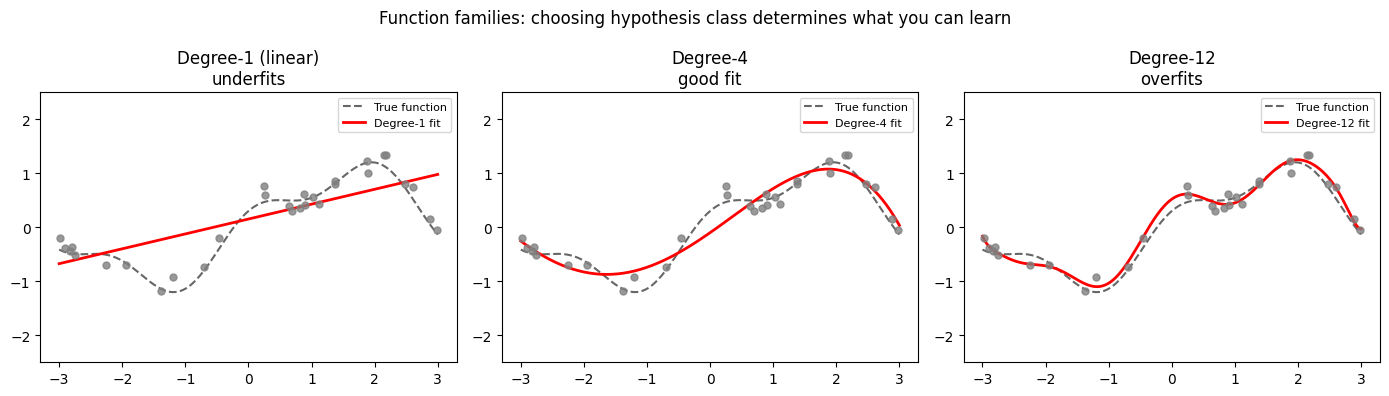

Key insight: The choice of family constrains what the learning algorithm can find.
Neural networks define a very expressive family — but expressivity is not the same
as learnability. Training dynamics matter as much as architecture.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Demonstrate: same task, very different function families
rng = np.random.default_rng(0)
x = np.linspace(-3, 3, 200)
y_true = np.sin(x) + 0.3 * np.cos(3 * x)  # true underlying function
x_obs = rng.uniform(-3, 3, 30)
y_obs = np.sin(x_obs) + 0.3 * np.cos(3 * x_obs) + rng.normal(0, 0.15, 30)

# Family 1: polynomials of varying degree
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
degrees = [1, 4, 12]
titles = ['Degree-1 (linear)\nunderfits', 'Degree-4\ngood fit', 'Degree-12\noverfits']

for ax, deg, title in zip(axes, degrees, titles):
    coeffs = np.polyfit(x_obs, y_obs, deg)
    y_pred = np.polyval(coeffs, x)
    ax.plot(x, y_true, 'k--', lw=1.5, label='True function', alpha=0.6)
    ax.plot(x, y_pred, 'r-', lw=2, label=f'Degree-{deg} fit')
    ax.scatter(x_obs, y_obs, s=25, color='gray', zorder=3, alpha=0.8)
    ax.set_title(title)
    ax.set_ylim(-2.5, 2.5)
    ax.legend(fontsize=8)

plt.suptitle('Function families: choosing hypothesis class determines what you can learn',
             fontsize=12)
plt.tight_layout()
plt.savefig('ch301_function_families.png', dpi=120)
plt.show()

print("Key insight: The choice of family constrains what the learning algorithm can find.")
print("Neural networks define a very expressive family — but expressivity is not the same")
print("as learnability. Training dynamics matter as much as architecture.")

## 4. A brief history in five inflection points

| Year | Event | Why it mattered |
|------|--------|-----------------|
| 1958 | Rosenblatt perceptron | First trainable linear classifier |
| 1986 | Rumelhart et al. — backprop | Efficient gradient computation for MLPs |
| 2012 | AlexNet wins ImageNet by 10pp | Deep CNNs + GPUs + large data = new paradigm |
| 2017 | Attention is All You Need | Transformers replace RNNs for sequences |
| 2020– | GPT-3 / scaling laws | Emergent capabilities at scale; LLMs as foundation models |

Each inflection required the same three things simultaneously: better algorithms, more data,
and faster hardware. None of the three alone was sufficient.

---

## 5. The supervised learning setup

Throughout Part X the default setting is supervised learning:

- Training set: $\{(x^{(i)}, y^{(i)})\}_{i=1}^N$
- Model: $\hat{y} = f_\theta(x)$
- Loss: $\mathcal{L}(\theta) = \frac{1}{N} \sum_i \ell(\hat{y}^{(i)}, y^{(i)})$
- Goal: $\theta^* \approx \arg\min_\theta \mathcal{L}(\theta)$

The subscript $\theta$ will always denote learnable parameters.
$\ell$ is the per-sample loss (MSE for regression, cross-entropy for classification).

---

## 6. What deep learning is not

- It is not magic. Every operation is differentiable arithmetic.
- It is not guaranteed to find a global minimum. It finds good local minima.
- It is not a replacement for understanding the problem. Architecture choices encode inductive biases.
- It is not data-agnostic. The distribution of training data determines what generalises.

---

## 7. Notation used throughout Part X

| Symbol | Meaning |
|--------|---------|
| $L$ | Number of layers |
| $n_l$ | Width of layer $l$ |
| $W^{[l]}$ | Weight matrix of layer $l$, shape $(n_l, n_{l-1})$ |
| $b^{[l]}$ | Bias vector of layer $l$, shape $(n_l,)$ |
| $a^{[l]}$ | Activation of layer $l$ |
| $z^{[l]}$ | Pre-activation: $W^{[l]} a^{[l-1]} + b^{[l]}$ |
| $\sigma$ | Activation function (context-dependent) |
| $\mathcal{L}$ | Scalar loss |
| $\nabla_\theta \mathcal{L}$ | Gradient of loss with respect to $\theta$ |

---

## 8. Summary

- Deep learning = parameterised function composition + gradient-based optimisation.
- Depth enables hierarchy of representations; this is why depth beats width in practice.
- Every architectural choice is a hypothesis about the structure of the problem.
- The mathematics is entirely the mathematics of Parts I–IX, applied at scale.

---

## 9. Forward and backward references

**Used here:** function composition *(ch054)*, gradient descent *(ch212)*, loss and residuals *(ch072)*,
activation functions *(ch064–065)*, partial derivatives *(ch210)*.

**This will reappear in ch306 — Backpropagation from Scratch**, where the abstract gradient
computation described here becomes an explicit algorithm operating on the layer notation
introduced in Section 7.